In [1]:
%load_ext autoreload
%autoreload 2

import os
import torchio as tio

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import nibabel as nib

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile
from math import ceil
import random
from tensorflow.keras import backend as K

#import wandb

import utils.processamento_dados as proc_dados
import utils.metricas_e_visualizacao as met_vil

2026-01-05 16:25:58.086695: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-05 16:25:58.778286: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-05 16:25:58.975143: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-05 16:26:00.382234: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Evita uso excessivo de memória
        print("GPU habilitada com sucesso!")
        print("Memory Growth habilitado para a GPU")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

tf.get_logger().setLevel('ERROR')

GPU habilitada com sucesso!
Memory Growth habilitado para a GPU


I0000 00:00:1767641196.170548    9366 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1767641196.171544    9366 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1767641196.171568    9366 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
# FUNÇÕES

def create_model_3d(input_shape, n_classes):
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # Camada 1
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 2
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 3
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # # Camada 4
    # x = layers.Conv3D(32, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    # x = layers.BatchNormalization()(x)
    # x = layers.LeakyReLU(negative_slope=0.3)(x)
    # # x = layers.MaxPooling3D(pool_size=(2, 2, 2), padding='same')(x)
    # x = layers.Dropout(0.3)(x)

    # Flatten e densas
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

In [4]:
# Definindo caminhos
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn"

train_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/train'
val_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/validation'
test_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/test'

oasis_dir = f'{dir_base}/OASIS/OASIS_NORMALIZED_MR2/validation'

results_dir_base = f'{dir_base}/ADNI/ADNI_NORMALIZED/results/ruidos_emci_lmci'
os.makedirs(results_dir_base, exist_ok=True)

results_dir = results_dir_base

transformations = ['noise']

In [5]:
# transform_name = None

# for item in transformations:
#     results_dir = f"{results_dir_base}/test_{item}"
#     if (not os.path.exists(results_dir)) or ((os.path.exists(results_dir) and len(os.listdir(results_dir)) < 3)):
#         os.makedirs(results_dir, exist_ok=True)
#         print(f"pasta test_{item} criada")
#         transform_name = item
#         break

In [ ]:
# Nome das classes
# adni_class_names = ['cn', 'emci', 'mci', 'lmci', 'ad']
adni_class_names = ['cn', 'mci', 'ad']
oasis_class_names = ['0.0', '0.5', '1.0']
used_class_names = [0, 1]

n_adni_classes = len(adni_class_names)

train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
    train_dir, 
    adni_class_names, 
    augment=True
)

print(f"N treino: {len(train_paths)}")

In [7]:
# # Crie uma pasta específica para esta saída massiva
# pdf_reports_dir = os.path.join(results_dir, "relatorios_10_pessoas")

# # Chame a nova função
# met_vil.generate_axial_pdf_reports_no_prediction(
#     images=train_images,
#     true_labels_onehot=train_labels,
#     class_names=adni_class_names,
#     output_dir=pdf_reports_dir,
#     max_samples=100
# )

Limitando relatórios a 100 amostras.
Gerando 100 relatórios PDF em: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/ruidos_emci_lmci/relatorios_10_pessoas
Processado 90/100 volumes (PDFs gerados)...
Geração de 100 relatórios PDF concluída.


In [8]:
val_images, val_labels, val_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(
    val_dir, 
    adni_class_names, 
    augment=True
)

print(f"N validation: {len(val_paths)}")

Passo 1: Coletando lista de arquivos...
Total de 442 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 442 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/442...
Processado 100/442...
Processado 150/442...
Processado 200/442...
Processado 250/442...
Processado 300/442...
Processado 350/442...
Processado 400/442...
Passo 4: Carregamento concluído.
N validation: 442


In [12]:
# Compila model
model = create_model_3d(train_images[2].shape, 2)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['binary_accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 156, 195, 160,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 156, 195, 160,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 156, 195, 160,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_3             │ (None, 52, 65, 54, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 52, 65, 54, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_4 (Conv3D)               │ (None, 52, 65, 54, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 52, 65, 54, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 52, 65, 54, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_4             │ (None, 18, 22, 18, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 18, 22, 18, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_5 (Conv3D)               │ (None, 18, 22, 18, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 18, 22, 18, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 18, 22, 18, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_5             │ (None, 6, 8, 6, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 8, 6, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │        73,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             

 Total params: 78,410 (306.29 KB)

 Trainable params: 78,322 (305.95 KB)

 Non-trainable params: 88 (352.00 B)

In [13]:
batch_size = 64

steps_per_epoch = len(train_paths) // batch_size
validation_steps = len(val_paths) // batch_size

train_generator = proc_dados.nifti_data_generator_3d(train_images, train_labels, batch_size)
val_generator = proc_dados.nifti_data_generator_3d(val_images, val_labels, batch_size)

epochs = 200

new_model_name_ker = (f"binary_classifier_noise_{epochs}_epochs_batch_{batch_size}_{n_adni_classes}_classes.keras")

# Parar caso fique {patience} épocas sem melhora
early_stopping = EarlyStopping(
    monitor='val_loss',     
    patience=30,                 
    verbose=1
)

# # Defina o nome do arquivo para salvar o melhor modelo
model_checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(results_dir, new_model_name_ker),    
    monitor='val_binary_accuracy',
    save_best_only=True, 
    mode='max', 
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)

log_path = os.path.join(results_dir, 'log_treino_ruido.csv')

csv_log = CSVLogger(log_path, append=False)

In [14]:
print(f"Iniciando treinamento do modelo {new_model_name_ker} para classes {adni_class_names}")

# Treinamento
history = model.fit(
    train_generator,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[model_checkpoint_callback, reduce_lr, csv_log, early_stopping]
)

Iniciando treinamento do modelo binary_classifier_noise_200_epochs_batch_64_3_classes.keras para classes ['cn', 'mci', 'ad']
Epoch 1/200


I0000 00:00:1767644057.025167  159325 service.cc:146] XLA service 0x7f78c40082c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767644057.025229  159325 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-05 17:14:17.398048: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-05 17:14:18.246957: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2026-01-05 17:14:23.506108: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.34GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-01-05 17:14:23.506181: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Al

24/24 ━━━━━━━━━━━━━━━━━━━━ 64s 935ms/step - binary_accuracy: 0.4609 - loss: 1.5195 - val_binary_accuracy: 0.3151 - val_loss: 1.2334 - learning_rate: 5.0000e-04
Epoch 2/200


2026-01-05 17:15:36.353641: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f16[4,1,3,3,3]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[63,1,156,195,160]{4,3,2,1,0}, f16[63,4,156,195,160]{4,3,2,1,0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-05 17:15:40.838288: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 5.484740068s
Trying algorithm eng0{} for conv (f16[4,1,3,3,3]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[63,1,156,195,160]{4,3,2,1,0}, f16[63,4,156,195,160]{4,3,2,1,0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBackwardFilter", backend

24/24 ━━━━━━━━━━━━━━━━━━━━ 56s 843ms/step - binary_accuracy: 0.5316 - loss: 1.3121 - val_binary_accuracy: 0.3438 - val_loss: 1.3555 - learning_rate: 5.0000e-04
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - binary_accuracy: 0.5775 - loss: 1.2095 - val_binary_accuracy: 0.3598 - val_loss: 1.5210 - learning_rate: 5.0000e-04
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 842ms/step - binary_accuracy: 0.6088 - loss: 1.1217 - val_binary_accuracy: 0.3254 - val_loss: 1.6973 - learning_rate: 5.0000e-04
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 837ms/step - binary_accuracy: 0.6257 - loss: 1.0515 - val_binary_accuracy: 0.3255 - val_loss: 1.8530 - learning_rate: 5.0000e-04
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 838ms/step - binary_accuracy: 0.6655 - loss: 0.9920 - val_binary_accuracy: 0.3439 - val_loss: 1.7859 - learning_rate: 5.0000e-04
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 839ms/step - binary_accuracy: 0.6906 - loss: 0.9558 - val_binary_accuracy: 0.3466 - val_loss: 1.8937 - learning_

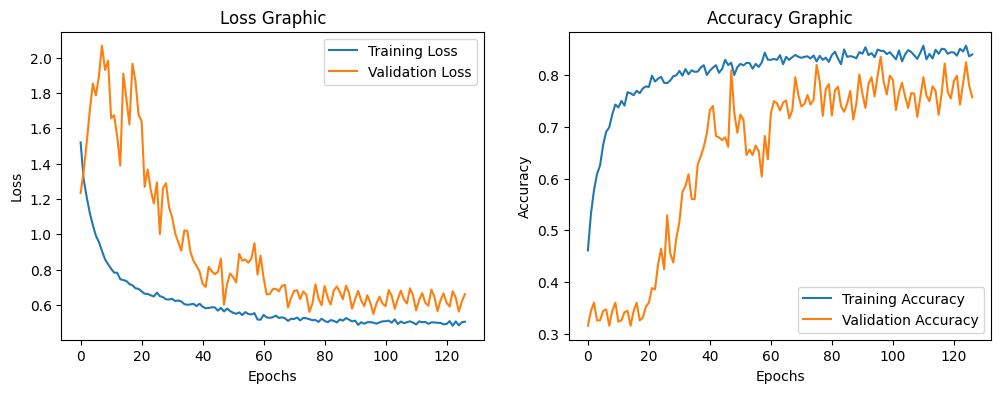

In [15]:
# Plotando o histórico de treinamento após o treinamento
met_vil.plot_training_history(history, f"{results_dir}")

### PREDIÇÃO TREINO

In [16]:
# # Crie uma pasta específica para esta saída massiva
# pdf_reports_dir = os.path.join(results_dir, "relatorios_axiais_treino")

# # Chame a nova função
# met_vil.generate_axial_pdf_reports(
#     model=model,
#     images=train_images,
#     true_labels_onehot=train_labels,
#     class_names=adni_class_names,
#     output_dir=pdf_reports_dir,
#     max_samples=2648
# )

Gerando 1599 relatórios PDF em: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/ruidos_emci_lmci/relatorios_axiais_treino


2026-01-05 17:57:45.682034: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce-window.91 = f32[1,52,65,54,4]{4,3,2,1,0} reduce-window(f32[1,156,195,160,4]{4,3,2,1,0} %broadcast.79, f32[] %constant.80), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x0_0x0_0x1_1x0_0}, to_apply=%region_1.87, metadata={op_type="AvgPool3D" op_name="functional_1_1/average_pooling3d_3_1/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-01-05 17:57:48.374522: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 3.692590538s
Constant folding an instructi

Processado 90/1599 volumes (PDFs gerados)...
Processado 190/1599 volumes (PDFs gerados)...
Processado 290/1599 volumes (PDFs gerados)...
Processado 390/1599 volumes (PDFs gerados)...
Processado 490/1599 volumes (PDFs gerados)...
Processado 590/1599 volumes (PDFs gerados)...
Processado 690/1599 volumes (PDFs gerados)...
Processado 790/1599 volumes (PDFs gerados)...
Processado 890/1599 volumes (PDFs gerados)...
Processado 990/1599 volumes (PDFs gerados)...
Processado 1090/1599 volumes (PDFs gerados)...
Processado 1190/1599 volumes (PDFs gerados)...
Processado 1290/1599 volumes (PDFs gerados)...
Processado 1390/1599 volumes (PDFs gerados)...
Processado 1490/1599 volumes (PDFs gerados)...
Processado 1590/1599 volumes (PDFs gerados)...
Geração de 1599 relatórios PDF concluída.


### PREDIÇÃO VALIDAÇÃO

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step
              precision    recall  f1-score   support

           0       0.57      0.93      0.71       137
           1       0.96      0.68      0.79       305

    accuracy                           0.76       442
   macro avg       0.76      0.81      0.75       442
weighted avg       0.84      0.76      0.77       442



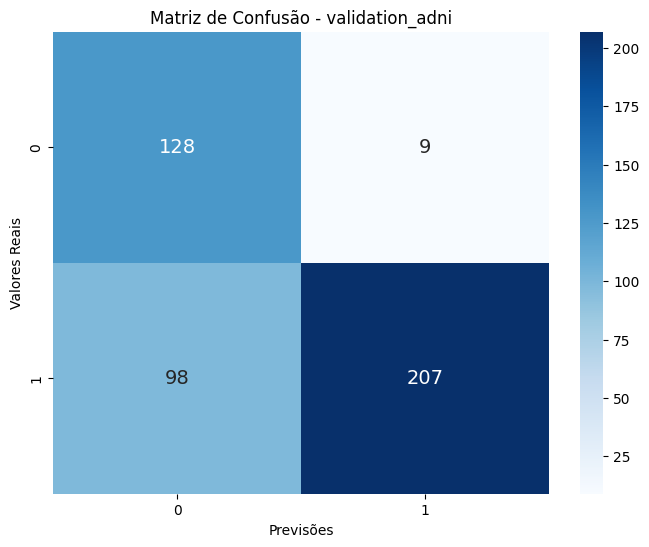

In [22]:
# Realizar predições para dados do conjunto validação
val_pred_labels, val_true_labels, val_pred = met_vil.get_predictions(val_images, val_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(val_true_labels, val_pred_labels, results_dir, 'validation_adni')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(val_true_labels, val_pred_labels, results_dir, 'validation_adni', used_class_names)

# Criar pdf com predições
val_pdf_path = os.path.join(results_dir, "validation_adni_predictions.pdf")
met_vil.create_pdf(val_paths, val_images, val_true_labels, val_pred_labels, val_pred, val_pdf_path, used_class_names)

### PREDIÇÃO TESTE

Passo 1: Coletando lista de arquivos...
Total de 227 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 227 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/227...
Processado 100/227...
Processado 150/227...
Processado 200/227...
Passo 4: Carregamento concluído.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step 
              precision    recall  f1-score   support

           0       0.49      0.95      0.64        73
           1       0.95      0.53      0.68       154

    accuracy                           0.66       227
   macro avg       0.72      0.74      0.66       227
weighted avg       0.80      0.66      0.67       227



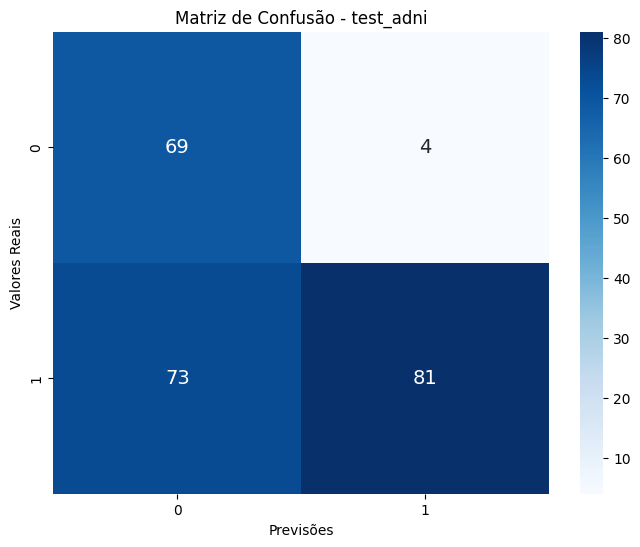

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/cnn/utils/metricas_e_visualizacao.py:119: RuntimeWarning: invalid value encountered in divide
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/cnn/utils/metricas_e_visualizacao.py:119: RuntimeWarning: invalid value encountered in cast
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter


In [23]:
test_images, test_labels, test_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(test_dir, adni_class_names)

# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = met_vil.get_predictions(test_images, test_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels, test_pred_labels, results_dir, 'test_adni')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels, test_pred_labels, results_dir, 'test_adni', used_class_names)

# Criar pdf com predições
test_pdf_path = os.path.join(results_dir, "test_adni_predictions.pdf")
met_vil.create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, used_class_names)

### PREDIÇÃO OASIS

Passo 1: Coletando lista de arquivos...
Total de 42 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 42 imagens...
Passo 3: Carregando e transformando imagens...
Passo 4: Carregamento concluído.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
              precision    recall  f1-score   support

           0       0.67      0.73      0.70        22
           1       0.67      0.60      0.63        20

    accuracy                           0.67        42
   macro avg       0.67      0.66      0.66        42
weighted avg       0.67      0.67      0.67        42



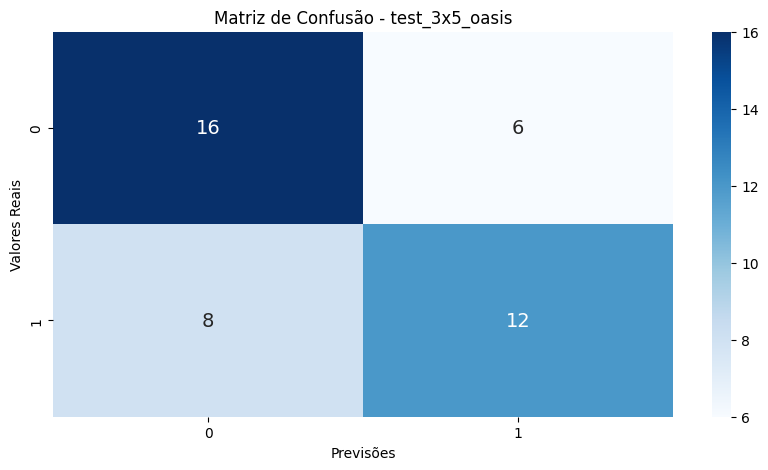

In [25]:
oasis_images, oasis_labels, oasis_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(oasis_dir, oasis_class_names)

# Realizar predições para dados do conjunto validação
oasis_pred_labels, oasis_true_labels, oasis_pred = met_vil.get_predictions(oasis_images, oasis_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(oasis_true_labels, oasis_pred_labels, results_dir, 'test_oasis')

# Obter matriz de confusão
cm_adjusted = confusion_matrix(oasis_true_labels, oasis_pred_labels)[0:2, :]
met_vil.plot_custom_confusion_matrix(cm_adjusted, used_class_names, used_class_names, results_dir, 'test_3x5_oasis')

# gathered_oasis_pred = []

# for i in range(len(oasis_pred_labels)):
#     if oasis_pred_labels[i] == 0:
#         gathered_oasis_pred.append(0)
#     else:
#         gathered_oasis_pred.append(1)

# # all_possible_numeric_labels = [0.0, 0.5, 1.0, 2.0, 3.0]

# cm_3x3_adjusted = confusion_matrix(oasis_true_labels, gathered_oasis_pred)[0:3, 0:3]

# # Chame a nova função para plotar a matriz ajustada (3x5)
# met_vil.plot_custom_confusion_matrix(cm_3x3_adjusted, used_class_names, used_class_names, results_dir, 'test_3x3_oasis')

# # Criar pdf com predições
# oasis_pdf_path = os.path.join(results_dir, "test_oasis_predictions.pdf")
# met_vil.create_pdf(oasis_paths, oasis_images, oasis_true_labels, gathered_oasis_pred, oasis_pred, oasis_pdf_path, used_class_names)